In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import snapatac2 as snap
import matplotlib.pyplot as plt
import seaborn as sns
import os

import sys
sys.path.append('/data1/normantm/multiome_collab')
from perturbseq import *
import multiome as mo

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
# env: scvi, snapatac: 2.6.0

import re

def _lane_num(sample_name):
    match = re.search(r'Lane(\d+)', sample_name)
    if match is None:
        raise ValueError(f"Could not parse lane number from sample name: {sample_name}")
    return match.group(1)


def cut_qc_metrics_by_called_aggregate(sample_names, figsize=(12, 5), savefig=None, downsampled=False):
    
    gex_merges = []
    atac_merges = []
    fdist_assigned_agg = None
    fdist_unassigned_agg = None

    for sample_name in sample_names:

        lane_num = _lane_num(sample_name)

        id_files = [file for file in os.scandir("/data1/normantm/multiome_collab/RPE1/ID_calling/250102") if "called_ids" in file.name] if not downsampled else [file for file in os.scandir("/data1/normantm/multiome_collab/RPE1/ID_calling/250107_downsample1k") if "called_ids" in file.name]
        called_ids = pd.read_csv([f for f in id_files if sample_name in f.name][0]).reset_index().groupby("CB").UMI.count().to_frame("n_guides")
        called_ids.index = called_ids.index.map(lambda cb: cb + f"-{lane_num}")

        adata_files = [file for file in os.scandir("/data1/normantm/multiome_collab/RPE1/cellranger_outs") if sample_name in file.name]
        adata_path = adata_files[0].path + '/outs/filtered_feature_bc_matrix.h5'

        adata_gex = sc.read_10x_h5(adata_path)
        adata_gex.var_names_make_unique()
        adata_gex.var["mito"] = adata_gex.var_names.str.startswith("MT-")
        sc.pp.calculate_qc_metrics(adata_gex, inplace=True, qc_vars=["mito"])
        adata_gex.obs_names = adata_gex.obs_names.str.replace(r'-\d+$', f'-{lane_num}', regex=True)

        gex_merge = adata_gex.obs.join(called_ids, how='left')
        gex_merge["Assigned"] = gex_merge["n_guides"].fillna(0).map(lambda n: n > 0)
        gex_merge = gex_merge[~gex_merge.index.duplicated(keep='first')]
        gex_merge["sample"] = sample_name

        atac_files = [file for file in os.scandir("/data1/normantm/multiome_collab/RPE1/intermediate_files") if sample_name in file.name and 'preprocessed_atac' in file.name]
        adata_atac = snap.read(atac_files[0].path, backed=None)
        adata_atac.obs_names = adata_atac.obs_names.str.replace(r'-\d+$', f'-{lane_num}', regex=True)
        adata_atac = adata_atac[~adata_atac.obs_names.duplicated(keep='first')].copy()

        shared_cells = gex_merge.index.intersection(adata_atac.obs_names)
        adata_atac = adata_atac[shared_cells].copy()

        atac_merge = adata_atac.obs.join(gex_merge[["Assigned", "sample"]], how='left')

        fdist_assigned = np.asarray(snap.metrics.frag_size_distr(adata_atac[atac_merge.Assigned], inplace=False))
        fdist_unassigned = np.asarray(snap.metrics.frag_size_distr(adata_atac[~atac_merge.Assigned], inplace=False))

        if fdist_assigned_agg is None:
            fdist_assigned_agg = fdist_assigned.copy()
        else:
            n = min(len(fdist_assigned_agg), len(fdist_assigned))
            fdist_assigned_agg = fdist_assigned_agg[:n] + fdist_assigned[:n]

        if fdist_unassigned_agg is None:
            fdist_unassigned_agg = fdist_unassigned.copy()
        else:
            n = min(len(fdist_unassigned_agg), len(fdist_unassigned))
            fdist_unassigned_agg = fdist_unassigned_agg[:n] + fdist_unassigned[:n]

        gex_merges.append(gex_merge.loc[shared_cells])
        atac_merges.append(atac_merge)

    gex_merge = pd.concat(gex_merges, axis=0)
    atac_merge = pd.concat(atac_merges, axis=0)

    gex_merge["total_counts"] = np.expm1(gex_merge["log1p_total_counts"])
    gex_merge["n_genes_by_counts"] = np.expm1(gex_merge["log1p_n_genes_by_counts"])

    fig, ax = plt.subplots(2, 3, figsize=figsize)

    sns.histplot(data=gex_merge, x='total_counts', kde=True, hue='Assigned', log_scale=True, ax=ax[0, 0])
    sns.histplot(data=gex_merge, x='n_genes_by_counts', kde=True, hue='Assigned', log_scale=True, ax=ax[0, 1])
    sns.histplot(data=gex_merge, x='pct_counts_mito', kde=True, hue='Assigned', ax=ax[0, 2])
    ax[0, 0].axvline(np.expm1(7), color='red', linestyle='--')
    ax[0, 1].axvline(np.expm1(6.5), color='red', linestyle='--')
    ax[0, 2].set_xlim([-2, 50])
    ax[0, 0].set_xlabel("Total UMI")
    ax[0, 1].set_xlabel("Unique genes")
    ax[0, 2].set_xlabel("UMIs from mitochondrial genes (%)")
    for i in range(3):
        ax[0, i].set_ylabel("Number of cells")

    sns.histplot(data=atac_merge, x='n_fragment', kde=True, hue='Assigned', ax=ax[1, 0])
    ax[1, 0].set_xlim([0, 6e4])
    ax[1, 0].axvline(1000, color='red', linestyle='--')
    sns.histplot(data=atac_merge, x='tsse', kde=True, hue='Assigned', ax=ax[1, 1])
    ax[1, 1].axvline(9, color='red', linestyle='--')
    ax[1,1].set_xlim([0,30])
    ax[1, 2].bar(np.arange(len(fdist_unassigned_agg) - 1), fdist_unassigned_agg[1:] / 1e5, alpha=0.5, label='False', rasterized=True)
    ax[1, 2].plot(np.arange(len(fdist_unassigned_agg) - 1), fdist_unassigned_agg[1:] / 1e5, alpha=0.8)
    ax[1, 2].bar(np.arange(len(fdist_assigned_agg) - 1), fdist_assigned_agg[1:] / 1e5, alpha=0.5, label='True', rasterized=True)
    ax[1, 2].plot(np.arange(len(fdist_assigned_agg) - 1), fdist_assigned_agg[1:] / 1e5, alpha=0.8)
    ax[1, 0].set_xlabel("Number of unique fragments")
    ax[1, 1].set_xlabel("TSS enrichment")
    ax[1, 2].set_xlabel("Fragment size (bp)")
    for i in range(3):
        ax[1, i].set_ylabel("Number of cells")

    fig.tight_layout()
    if savefig is not None:
        plt.savefig(savefig)
    fig.show()

    return gex_merge, atac_merge

sample_names = [f"Lane{i}" for i in range(1,7)]
gexqc, atacqc = cut_qc_metrics_by_called_aggregate(sample_names, figsize=(12, 5), savefig='plots/S1b_metrics.pdf', downsampled=False)

In [23]:
expt = mo.MultiomeExperiment.load('/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_multiomeTFs.pkl')
expt.id_dir = '/data1/normantm/multiome_collab/RPE1/ID_calling/250102'

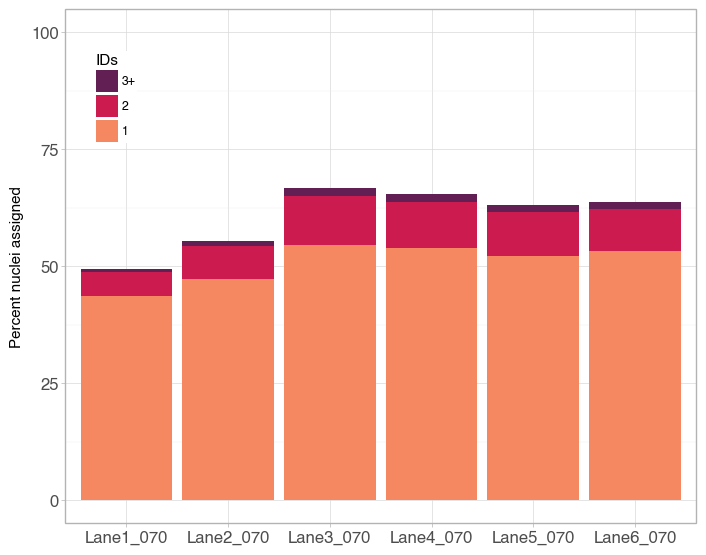

63.388774562561


/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3.5 x 2.75 in image.
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: plots/S1a_assignment.pdf
2026-07-16 14:57:12 - INFO - maxp pruned
2026-07-16 14:57:12 - INFO - cmap pruned
2026-07-16 14:57:12 - INFO - post pruned
2026-07-16 14:57:12 - INFO - FFTM dropped
2026-07-16 14:57:12 - INFO - GPOS pruned
2026-07-16 14:57:12 - INFO - GSUB pruned
2026-07-16 14:57:12 - INFO - glyf pruned
2026-07-16 14:57:12 - INFO - Added gid0 to subset
2026-07-16 14:57:12 - INFO - Added first four glyphs to subset
2026-07-16 14:57:12 - INFO - Closing glyph list over 'GSUB': 31 glyphs before
2026-07-16 14:57:12 - INFO - Glyph names: ['.notdef', '.null', 'D', 'I', 'L', 'P', 'a', 'c', 'd', 'e', 'five', 'four', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'one', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three',

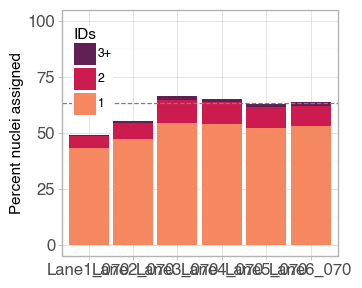

,calls,n_cells,pct_nuclei,library
1,1,4555,54.498684,Lane3_070
2,2,876,10.480976,Lane3_070
3,3+,146,1.746829,Lane3_070
1,1,4764,53.145917,Lane6_070
2,2,819,9.136546,Lane6_070
3,3+,135,1.506024,Lane6_070
1,1,3812,43.555759,Lane1_070
2,2,448,5.118830,Lane1_070
3,3+,56,0.639854,Lane1_070
1,1,3612,47.289866,Lane2_070


In [11]:
df = expt.assignment_rate_by_lane()
print(df.groupby('library').pct_nuclei.sum().median())
expt.assignment_rate_by_lane(axhline = df.groupby('library').pct_nuclei.sum().median(), savefig = 'plots/S1a_assignment.pdf', figsize = (3.5, 2.75))

In [16]:
from Bio.SeqIO.QualityIO import FastqGeneralIterator
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcdefaults()
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

def get_guide_reads(fastq_file, lib):

    guide_reads, quals = [], []
    with open(fastq_file) as fastq:
        for title, seq, qual in tqdm(FastqGeneralIterator(fastq_file)):
            if np.mean([ord(c) - 33 for c in qual]) >= 30 and str(seq).find('GTTTAAGAGC') != -1:
                guide_reads.append(str(seq).partition('GTTTAAGAGC')[0][-20:])
    colname = f"reads_{lib}"
    return pd.DataFrame({lib: guide_reads}).value_counts().to_frame(colname).rename_axis("protospacer").reset_index().set_index("protospacer")

df_reads = get_guide_reads("/data1/normantm/eli/T7/202412_multiome_TFs/libqc/070-MultiomeTFs_S1_L001_R1_001.fastq", "070_lib")
guides = pd.read_csv('/data1/normantm/eli/T7/202412_multiome_TFs/libqc/241105_multiomeTFlib_v2.csv').set_index('protospacer')
guides = guides.join(df_reads, how = 'inner')

504998it [00:06, 77666.43it/s]


In [ ]:
guides['lib_pct'] = guides.reads_070_lib / guides.reads_070_lib.sum()
df_lib = guides[['guide_identity', 'lib_pct']].set_index('guide_identity')
df_cells = expt.gex.obs.identity.value_counts().to_frame('ncells')
df_plot = df_lib.join(df_cells).dropna()

In [7]:
df_plot['expt_pct'] = df_plot.ncells / df_plot.ncells.sum()
df_plot['lfc'] = np.log2(df_plot.expt_pct / df_plot.lib_pct)
df_plot.sort_values('lfc', ascending = False).head(50)
df_plot['guide_target'] = df_plot.index.str.split('_').str[0]
df_plot['guide_number'] = df_plot.groupby('guide_target').cumcount() + 1
df_plot['guide_name'] = df_plot.guide_target + '_g' + df_plot.guide_number.astype(str)

In [9]:
df_plot.query("index.str.contains('PRDM')")

,lib_pct,ncells,expt_pct,lfc,guide_target,guide_number,guide_name
guide_identity,,,,,,,
PRDM16_GTCAATCTGACACCCCTCGC,0.005532,1438.0,0.057225,3.370676,PRDM16,1,PRDM16_g1
PRDM16_GCGGCGGCGGCGCGACGATG,0.009990,3450.0,0.137292,3.780626,PRDM16,2,PRDM16_g2
PRDM1_GGAAGAGAGGAAGCTCTCGG,0.008218,50.0,0.001990,-2.046154,PRDM1,1,PRDM1_g1


2026-07-16 15:18:45 - INFO - maxp pruned
2026-07-16 15:18:45 - INFO - cmap pruned
2026-07-16 15:18:45 - INFO - post pruned
2026-07-16 15:18:45 - INFO - FFTM dropped
2026-07-16 15:18:45 - INFO - GPOS pruned
2026-07-16 15:18:45 - INFO - GSUB pruned
2026-07-16 15:18:45 - INFO - glyf pruned
2026-07-16 15:18:45 - INFO - Added gid0 to subset
2026-07-16 15:18:45 - INFO - Added first four glyphs to subset
2026-07-16 15:18:45 - INFO - Closing glyph list over 'GSUB': 59 glyphs before
2026-07-16 15:18:45 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'uni0008', 'zero']
2026-07-16 15:18:45 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 18, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 38

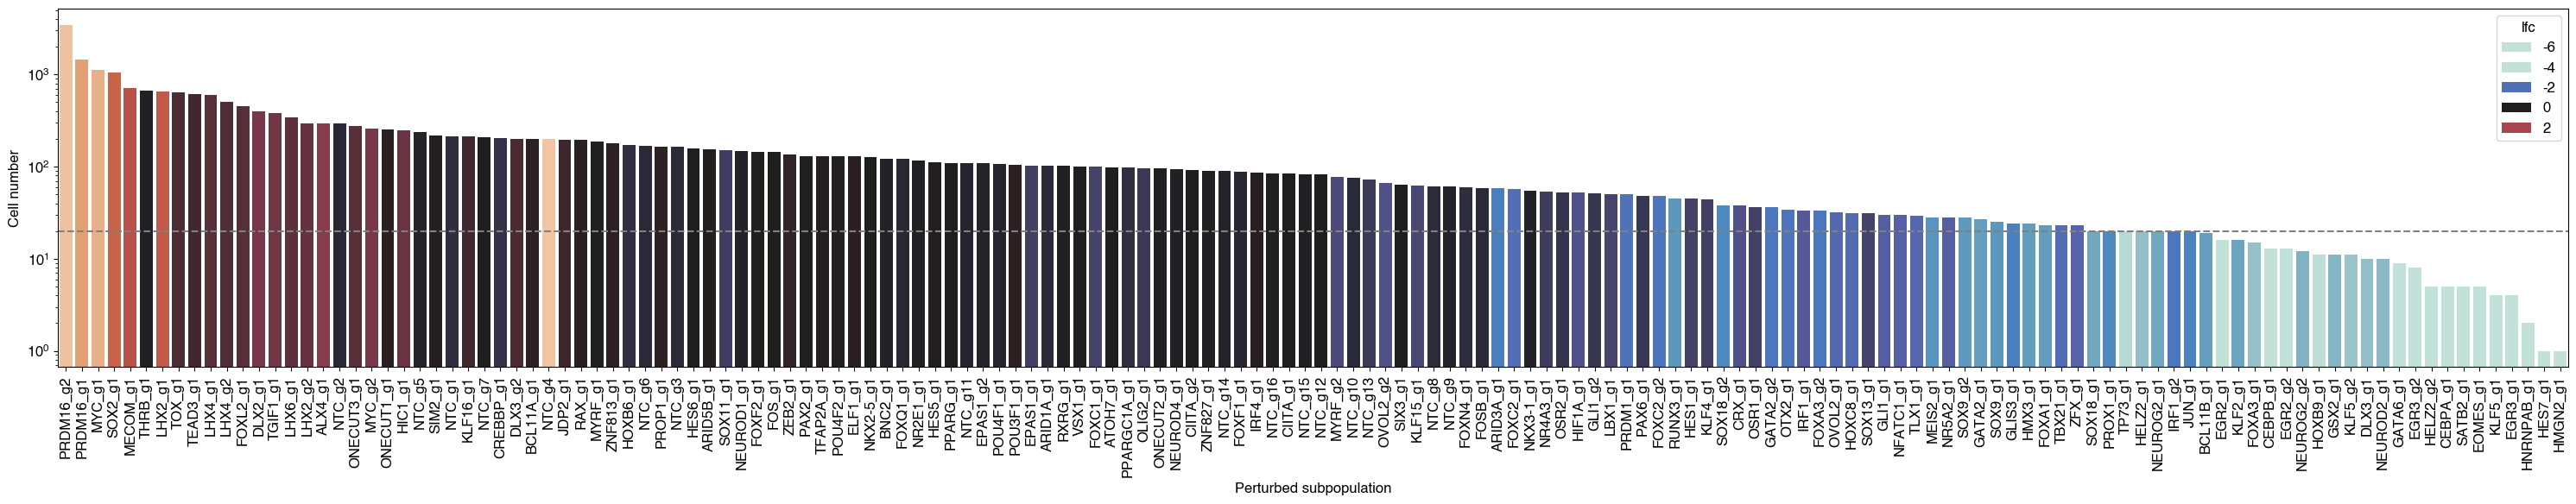

In [58]:
plt.figure(figsize = (30,6))
sns.barplot(df_plot.sort_values('ncells', ascending=False), x = 'guide_name', y = 'ncells', hue = 'lfc', palette = 'icefire', hue_norm=(-4,4))
plt.yscale('log')
plt.xticks(rotation = 90)
plt.axhline(y = 20, color = 'grey', linestyle = '--')
plt.ylabel("Cell number")
plt.xlabel("Perturbed subpopulation")
plt.tight_layout()
plt.savefig("S1c_ncells.pdf")
plt.show()

In [56]:
df_plot.query("ncells >= 20").guide_target.nunique()

104

In [63]:
len(df_plot.query("ncells >= 20"))

133

In [31]:
df_table = df_lib.join(df_cells)
df_table['ncells'] = df_table.ncells.fillna(0)
df_table['expt_pct'] = df_table.ncells / df_table.ncells.sum()
df_table['lfc'] = np.log2(df_table.expt_pct / df_table.lib_pct)
df_table['guide_target'] = df_table.index.str.split('_').str[0]
df_table['guide_number'] = df_table.groupby('guide_target').cumcount() + 1
df_table['guide_name'] = df_table.guide_target + '_g' + df_table.guide_number.astype(str)

/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2


In [33]:
df_table.to_csv("intermediate_files/TableS1_multiome_guides.csv")

In [2]:
df_doubles = pd.read_csv("intermediate_files/scvi_direct_global_interaction_metrics.csv", index_col = 0)
expt = mo.MultiomeExperiment.load('/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_multiomeTFs.pkl')
tgts = expt.gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")

In [3]:
from matplotlib.colors import to_rgba
from pycirclize import Circos

df = df_doubles.copy()
df_primed = df_doubles[['primed_ab', 'primed_ba', 'is_primed_no_homolog']].copy().reset_index()
df_primed[['a','b']] = df_primed.guide_target.str.split('_', expand = True)
df_primed['connection_score'] = df_primed.apply(lambda df: np.nan if not df.is_primed_no_homolog else np.nanmax([df.primed_ab, df.primed_ba]), axis = 1)
df_primed['direction'] = df_primed.apply(
    lambda df:
        np.nan if not df.is_primed_no_homolog else
        'ab' if pd.isna(df.primed_ba) else
        'ba' if pd.isna(df.primed_ab) else
        'ab' if df.primed_ab > df.primed_ba else
        'ba',
    axis=1,
)

singles = pd.read_csv('/data1/normantm/eli/T7/rpe1_paper/intermediate_files/circos_singles.csv')

mtx = pd.DataFrame(0.0, index = singles.sort_values('group').guide_target, columns = singles.sort_values('group').guide_target)
for idx, row in df_primed.iterrows():
    if np.isnan(row.connection_score):
        continue
    if row.primed_ab > 0:
        mtx.loc[row.a, row.b] += row.primed_ab
    if row.primed_ba > 0:
        mtx.loc[row.b, row.a] += row.primed_ba

mtx = np.clip(mtx, 0, 2)
gex = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_multiome_gex.h5ad')
tgts = gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")
palette = sns.color_palette("husl", len(tgts)).as_hex()
color_mapping = dict(zip(tgts.sort_index().index.tolist(), palette))
gene_order = singles.sort_values('group').guide_target

singles_grouped = pd.read_csv("/data1/normantm/eli/T7/rpe1_paper/intermediate_files/circos_singles_grouped.csv")
spaces = singles_grouped.space.tolist()
spaces = [s / 2 if s == 1 else s for s in spaces]
spaces = list(map(lambda x: x/2, spaces))

In [ ]:
mtx_plot = mtx.replace(0, np.nan).drop(['ARID1A', 'MYRF'], axis = 0)
# cg = sns.clustermap(mtx, row_cluster = False, col_cluster = False, figsize = (12,12), vmax = 1, xticklabels = 1, yticklabels = 1, vmin = 0, cmap = 'viridis', method = 'ward')
plt.figure(figsize = (12,12))
ax = sns.heatmap(mtx_plot, vmax = 1, xticklabels = 1, yticklabels = 1, vmin = 0, cmap = 'viridis', cbar = None)
ax.set_facecolor('#dddddd')
plt.xlabel("Perturbation target")
plt.ylabel("Motif")
plt.savefig("plots/S1D_priming_heatmap.pdf")
plt.show()

In [38]:
df_doubles['category'] = df_doubles.apply(lambda df: 'primed_unidirectional' if df.is_primed_no_homolog and not df.bidirectional else 'primed_bidirectional' if df.is_primed_no_homolog and df.bidirectional else 'non_primed', axis=1)
df_doubles.category.value_counts()

category
non_primed               686
primed_unidirectional    482
primed_bidirectional      57
Name: count, dtype: int64

2026-09-26 15:42:31 - INFO - maxp pruned
2026-09-26 15:42:31 - INFO - cmap pruned
2026-09-26 15:42:31 - INFO - post pruned
2026-09-26 15:42:31 - INFO - FFTM dropped
2026-09-26 15:42:31 - INFO - GPOS pruned
2026-09-26 15:42:31 - INFO - GSUB pruned
2026-09-26 15:42:31 - INFO - glyf pruned
2026-09-26 15:42:31 - INFO - Added gid0 to subset
2026-09-26 15:42:31 - INFO - Added first four glyphs to subset
2026-09-26 15:42:31 - INFO - Closing glyph list over 'GSUB': 10 glyphs before
2026-09-26 15:42:31 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'four', 'nonmarkingreturn', 'one', 'six', 'two', 'uni0008', 'zero']
2026-09-26 15:42:31 - INFO - Glyph IDs:   [0, 1, 2, 3, 21, 22, 23, 25, 27, 29]
2026-09-26 15:42:31 - INFO - Closed glyph list over 'GSUB': 10 glyphs after
2026-09-26 15:42:31 - INFO - Glyph names: ['.notdef', '.null', 'eight', 'four', 'nonmarkingreturn', 'one', 'six', 'two', 'uni0008', 'zero']
2026-09-26 15:42:31 - INFO - Glyph IDs:   [0, 1, 2, 3, 21, 22, 23, 25, 27, 29]
2026-09

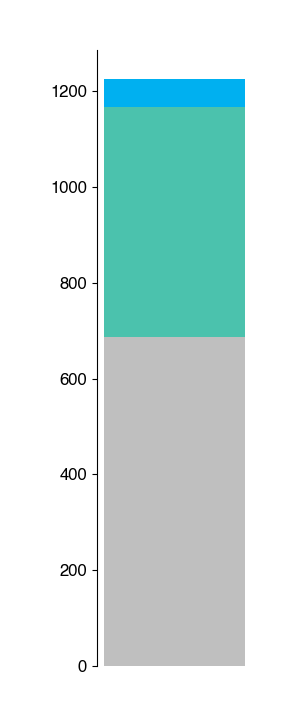

In [51]:
counts = df_doubles.category.value_counts().reindex(['non_primed', 'primed_unidirectional', 'primed_bidirectional'])

fig, ax = plt.subplots(figsize=(2, 8))

bottom = 0
for value, color in zip(counts, ['#bfbfbf', '#4bc2ad', '#00b0f0']):
    ax.bar(0, value, bottom=bottom, color=color, width=0.8)
    bottom += value

ax.set_xticks([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
plt.savefig('plots/S1E_priming_bar.pdf')